# Ejercicio 3

<span style="color:green">Este ejercicio se ha completado de manera local usando una gráfica RTX 4060</span>

In [2]:
import matplotlib
import matplotlib.image as pltim
import matplotlib.pyplot as plt
import numpy as np
import time
import os
from numba import jit, njit, cuda, prange
 

Código extraido de la práctica 1

In [3]:
folder = "images"  # Asegurar que el link anterior se llamada images

def list_jpg_files(folder_path):
  jpg_files = []
  for filename in os.listdir(folder_path):
    if filename.lower().endswith(".jpg"):
      jpg_files.append(filename)
  return jpg_files

jpg_files_list = list_jpg_files(folder)

def showImage(image):
  plt.imshow(image, cmap = matplotlib.cm.Greys_r)
  plt.show()

360 640
Processing image images/4k.jpg
2160 3840
Execution time: 0.015005 seconds


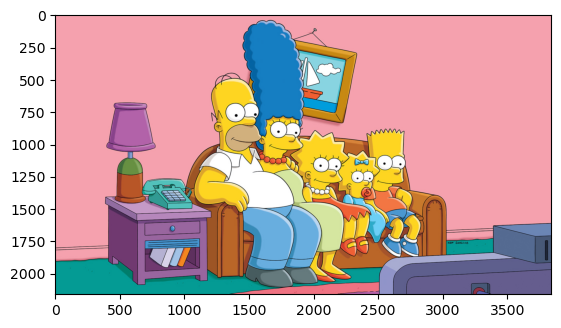

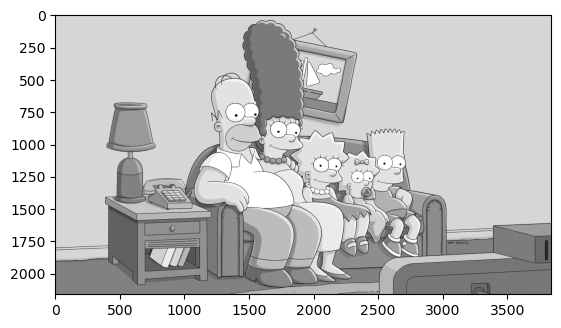

Processing image images/8k.jpg
4320 7680
Execution time: 0.056000 seconds


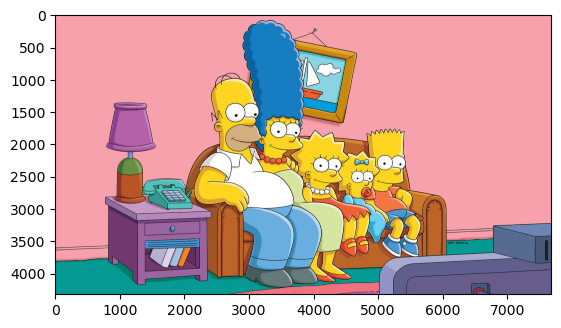

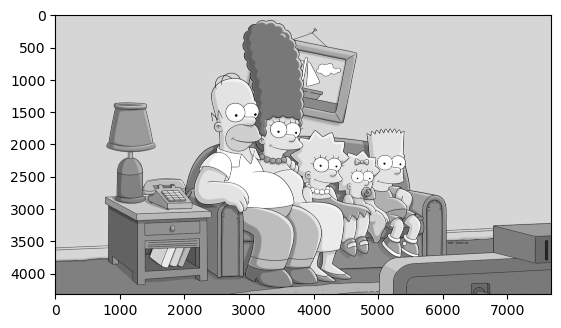

Processing image images/FHD.jpg
1080 1920
Execution time: 0.005999 seconds


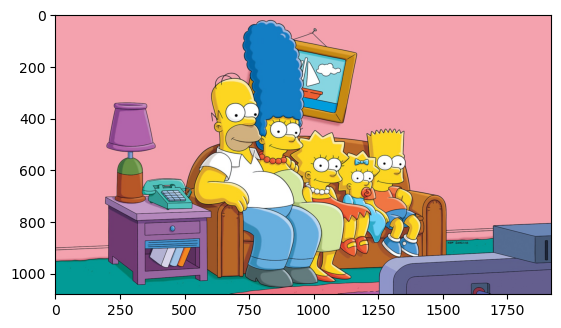

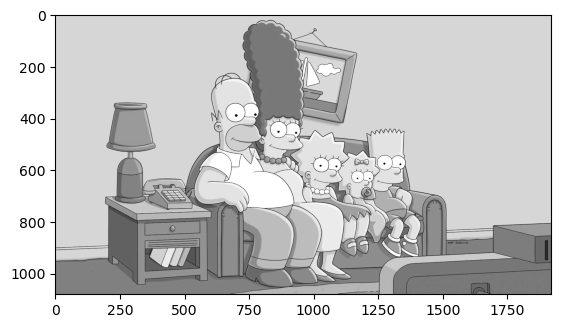

Processing image images/HD.jpg
720 1280
Execution time: 0.002004 seconds


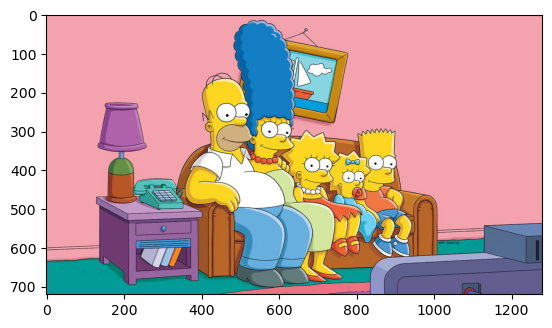

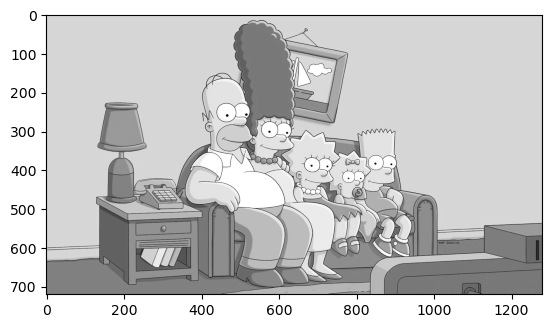

Processing image images/SD.jpg
360 640
Execution time: 0.003006 seconds


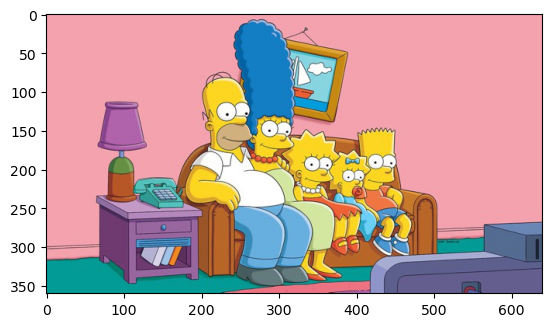

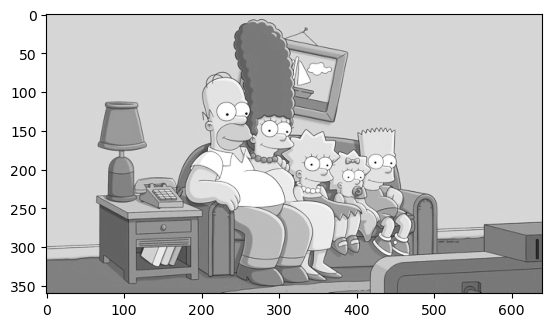

In [4]:

# Añadimos el decorador de numba para compilar la función. 
@jit(nopython=True)
def rgb2gray_ejercicio2(image):
  imageHeight = len(image)
  imageWidth = len(image[0])
  print(imageHeight, imageWidth)
  greyImage = np.empty((imageHeight, imageWidth), dtype=np.uint8)
  # Y mantenemos el orden de ejecución:
  for i in range(imageHeight):
      for j in range(imageWidth):
          greyImage[i][j] = np.int8(image[i][j][0]*0.2989 + image[i][j][1]*0.5870 + image[i][j][2] * 0.1140)
  return greyImage

tiempos_ejecución_ejercicio2 = []

# Primero una llamdada en frío. 
image = pltim.imread('images/SD.jpg')
rgb2gray_ejercicio2(image)

# Recorrer la lista para convertir a gris
for image_file in jpg_files_list:
  
  image_file = folder+"/"+image_file
  image = pltim.imread(image_file)
  print(f"Processing image {image_file}")

  start_time = time.time()

  greyimage = rgb2gray_ejercicio2(image)

  end_time = time.time()
  execution_time = end_time - start_time
  tiempos_ejecución_ejercicio2.append(execution_time)
  print(f"Execution time: {execution_time:.6f} seconds")

  showImage(image)
  showImage(greyimage)

360 640
Processing image images/4k.jpg
2160 3840
Execution time: 0.002999 seconds


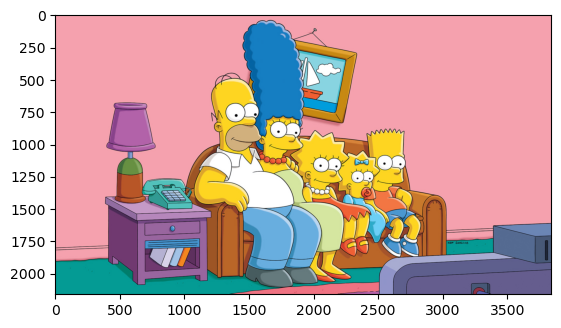

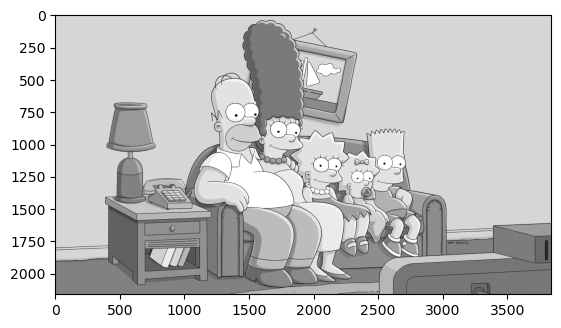

Processing image images/8k.jpg
4320 7680
Execution time: 0.010999 seconds


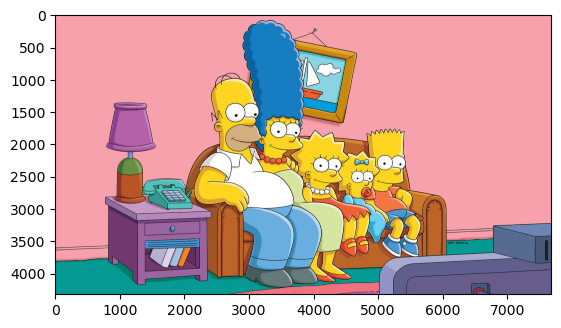

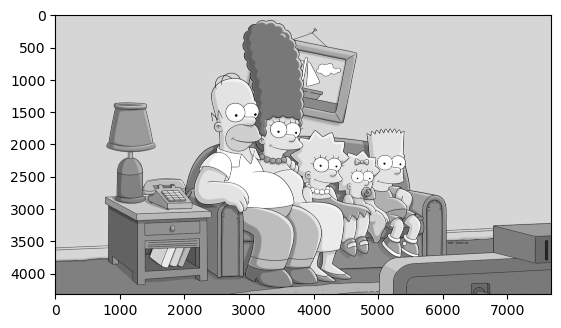

Processing image images/FHD.jpg
1080 1920
Execution time: 0.001999 seconds


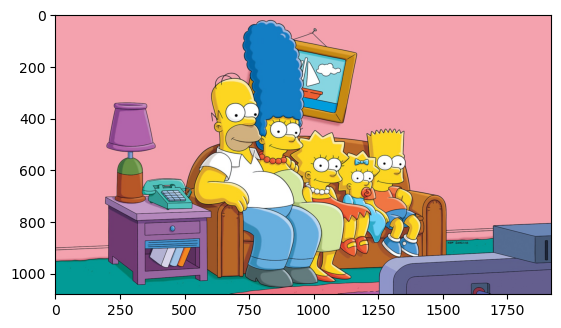

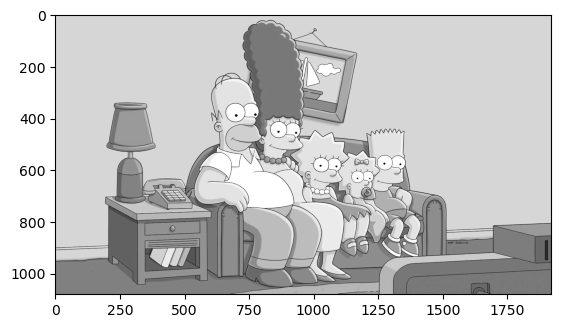

Processing image images/HD.jpg
720 1280
Execution time: 0.000995 seconds


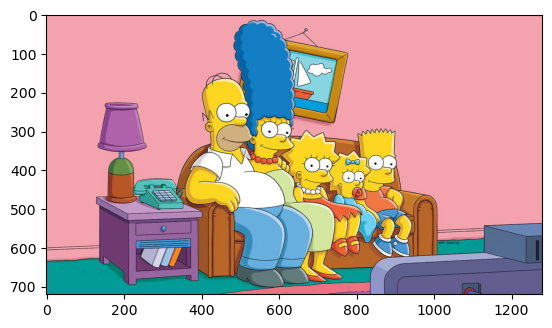

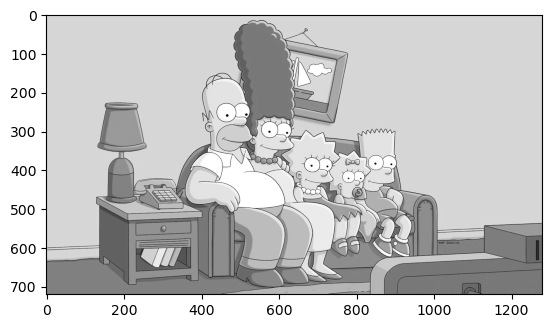

Processing image images/SD.jpg
360 640
Execution time: 0.001000 seconds


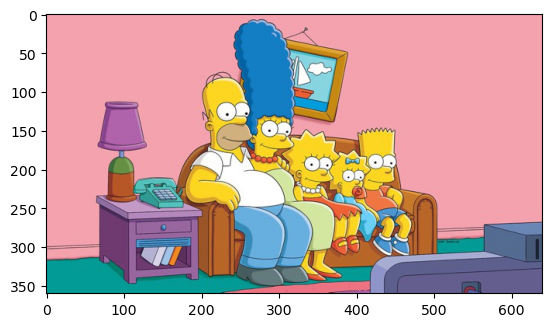

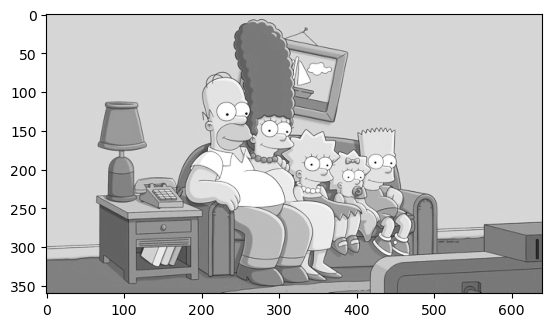

In [5]:


@jit(nopython=True, parallel=True)
def rgb2gray_ejercicio3(image):
  imageHeight = len(image)
  imageWidth = len(image[0])
  print(imageHeight, imageWidth)
  greyImage = np.empty((imageHeight, imageWidth), dtype=np.uint8)
  # Y mantenemos el orden de ejecución:
  for i in prange(imageHeight):
      for j in range(imageWidth):
          greyImage[i][j] = np.int8(image[i][j][0]*0.2989 + image[i][j][1]*0.5870 + image[i][j][2] * 0.1140)
  return greyImage

tiempos_ejecución_ejercicio3 = []

# Primero una llamdada en frío. 
image = pltim.imread('images/SD.jpg')
rgb2gray_ejercicio3(image)

# Recorrer la lista para convertir a gris
for image_file in jpg_files_list:
  
  image_file = folder+"/"+image_file
  image = pltim.imread(image_file)
  print(f"Processing image {image_file}")

  start_time = time.time()

  greyimage = rgb2gray_ejercicio3(image)

  end_time = time.time()
  execution_time = end_time - start_time
  tiempos_ejecución_ejercicio3.append(execution_time)
  print(f"Execution time: {execution_time:.6f} seconds")

  showImage(image)
  showImage(greyimage)

In [17]:

@cuda.jit
def rgb2gray_kernel(image, greyImage):

    # el bucle desaparece, ahora cada hilo tiene asociado un elemento de la matriz 
    [i,j] = cuda.grid(2)

    if i < image.shape[0] and j < image.shape[1]:
        greyImage[i][j] = np.int8(image[i][j][0]*0.2989 + image[i][j][1]*0.5870 + image[i][j][2] * 0.1140)

Adapatación del lanzador de kernels del ejercicio 2

In [ ]:
def rgb2gray_cuda(image):
    n = image.shape[0] * image.shape[1]
    imageHeight = len(image)
    imageWidth = len(image[0])
    print(imageHeight, imageWidth)
    #gestionando memoria
    image_device = cuda.to_device(image.astype(np.float64))
    output_device = cuda.device_array((imageHeight, imageWidth), dtype=np.float64)
    # Configurar lanzamiento dinámico
    threadsperblock = (16, 16)
    #notese que el tamaño del grid es asimetrico ya que la imagen no es cuadrada
    blockspergrid = (int(np.ceil(imageHeight / threadsperblock[0])),  int(np.ceil(imageWidth  / threadsperblock[1])) )

    # Lanzar kernel
    rgb2gray_kernel[blockspergrid, threadsperblock](image_device, output_device)

    return output_device.copy_to_host()

Processing image images/4k.jpg
2160 3840
Execution time: 0.292532 seconds


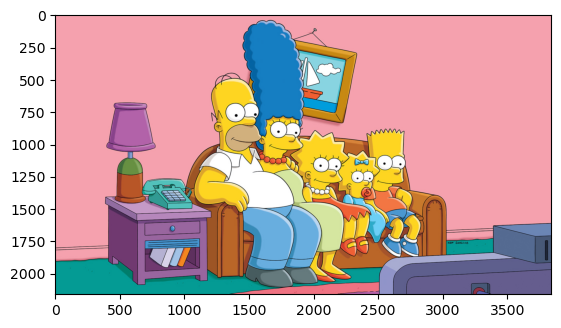

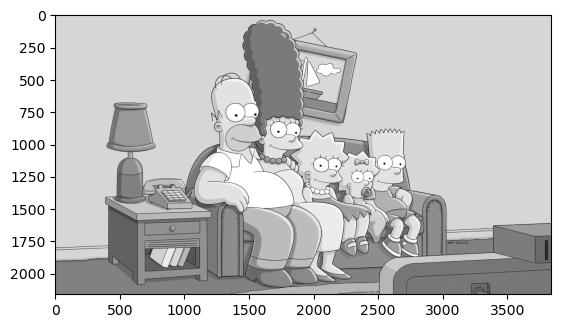

Processing image images/8k.jpg
4320 7680
Execution time: 0.783995 seconds


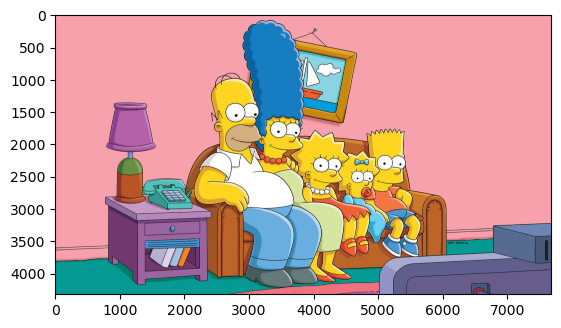

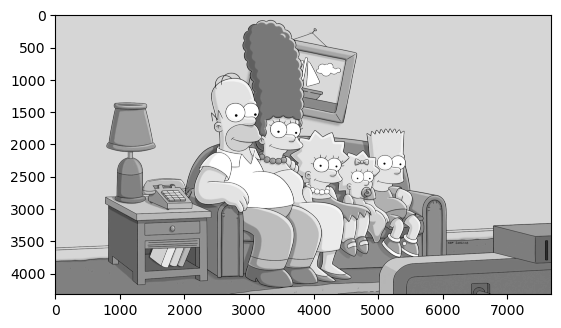

Processing image images/FHD.jpg
1080 1920
Execution time: 0.103013 seconds


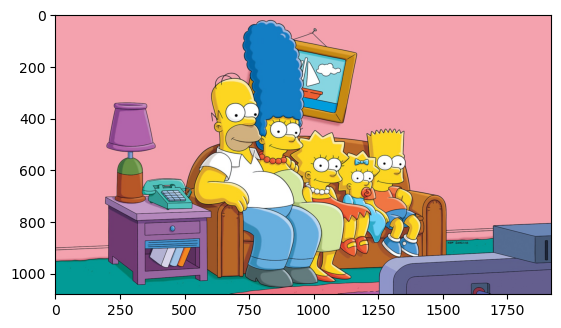

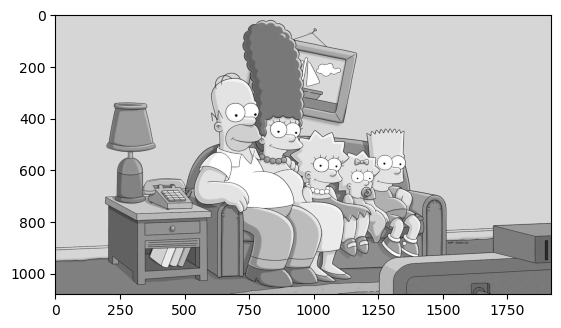

Processing image images/HD.jpg
720 1280
Execution time: 0.033516 seconds


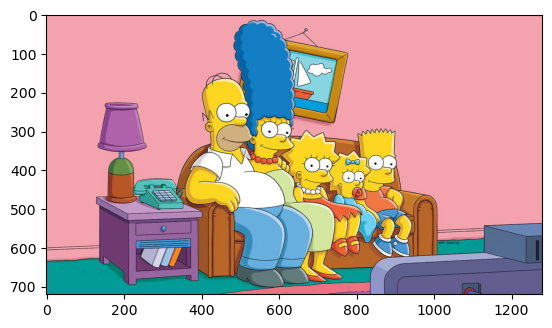

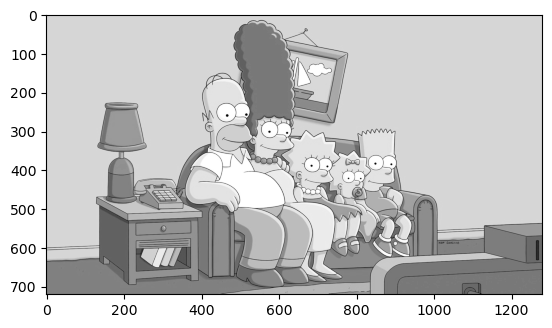

Processing image images/SD.jpg
360 640
Execution time: 0.010001 seconds


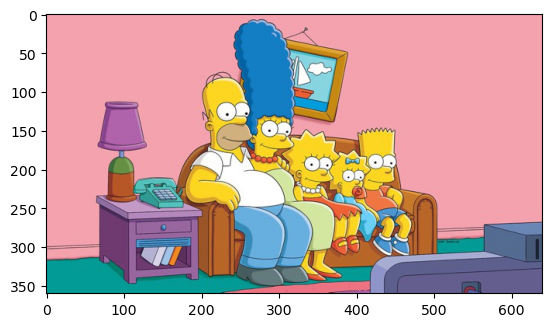

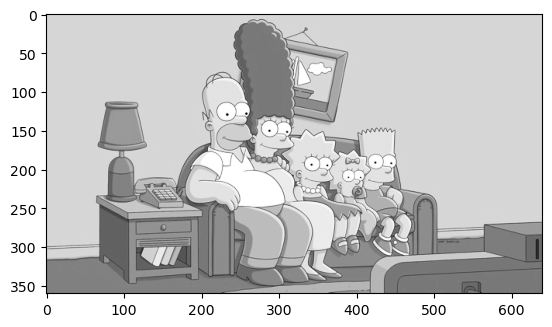

In [36]:
tiempos_ejecucion_cuda = []
for image_file in jpg_files_list:
  
  image_file = folder+"/"+image_file
  image = pltim.imread(image_file)
  print(f"Processing image {image_file}")

  start_time = time.time()

  greyimage = rgb2gray_cuda(image)
  cuda.synchronize()
  end_time = time.time()
  execution_time = end_time - start_time
  tiempos_ejecucion_cuda.append(execution_time)
  print(f"Execution time: {execution_time:.6f} seconds")

  showImage(image)
  showImage(greyimage)

In [39]:
import pandas as pd

my_dict = {}

imagenes = ['4k', '8k', 'FHD', 'SD', 'HD']
for a, b in zip(imagenes, tiempos_ejecucion_cuda):
    my_dict[a] = b 

df = pd.DataFrame.from_dict(my_dict, orient='index', columns=['Tiempo de ida, procesamiento y vuelta'])
df['fps_cuda'] = 30/df['Tiempo de ida, procesamiento y vuelta']
df['tiempo simd'] = tiempos_ejecución_ejercicio2
df['fps_simd'] = 30/df['tiempo simd']
df['tiempo paralelo'] = tiempos_ejecución_ejercicio3
df['fps_paralelo'] = 30/df['tiempo paralelo']

df

,"Tiempo de ida, procesamiento y vuelta",fps_cuda,tiempo simd,fps_simd,tiempo paralelo,fps_paralelo
4k,0.292532,102.552811,0.015005,1999.382210,0.002999,10002.314785
8k,0.783995,38.265531,0.056000,535.712060,0.010999,2727.529534
FHD,0.103013,291.225944,0.005999,5000.759876,0.001999,15010.034594
SD,0.033516,895.084010,0.002004,14968.965025,0.000995,30160.383509
HD,0.010001,2999.645275,0.003006,9981.684912,0.001000,30002.174535


Como podemos observar otra vez CUDA no sale bien parada por su cuello de botella causada por el tiempo de transmisión. En un problema con imagenes mucho más grandes seguro que sería más eficiente que la alternativa en CPU

Por último, respondiendo a cómo haría para mejorar el algoritmo:

Memoria compartida: cargar píxeles en shared memory antes de operar, evitando accesos repetidos a memoria global (lenta).

Cercanía en memoria: los accesos a image[i][j][c] son contiguos en memoria gracias al orden row-major de NumPy, lo que maximiza el ancho de banda. En teoría esto ya debería ser óptimo.

Evitar divergencia de warp: el if i < H and j < W causa que algunos threads no trabajen, minimizable eligiendo tamaños de bloque que dividan bien las dimensiones de la imagen.

Occupancy: bloques de (16, 16, 4) = 1024 threads (máximo por bloque), maximizando la ocupación de los SMs.

Memoria pinned: usar cuda.pinned_array en CPU para acelerar transferencias CPU↔GPU.